In [1]:
%load_ext autoreload

%autoreload 2

In [3]:
import sys
sys.path.append('.')

from matplotlib import rc
import matplotlib as mpl
from sklearn.preprocessing import StandardScaler
rc('font',**{'family':'libertine'})
rc('text', usetex=True)
# rc('pgf', texsystem='pdflatex', rcfonts=False)
rc('text.latex', preamble=r'\usepackage{scalerel,stackengine,amsmath,amsfonts}')

FIGURES_PATH = '../../../Dropbox/Програми/Overleaf/Frequentist Consistency of (causal) PFNs (ICML)/figures/'

In [4]:
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

import seaborn as sns
import pandas as pd

sample_name = r"Amount of measured confounding, $\Delta$"
dim_cov_name = r"$d_x$"

In [5]:
from joblib import Parallel, delayed

In [6]:
from DATA_standard.gen_standard_syn import generate_multiple_datasets, generate_single_dataset

In [9]:
# num_features_list = [5, 10, 50, 500]
num_features_list = [5, 50, 100]
n_datasets = 10

dfs = []

for num_features in tqdm(num_features_list):

    def sample_dataset():
        _, _, A, Y, Y0, Y1 = generate_single_dataset(
            dataset_id=0,
            num_samples=1000,
            num_features=num_features,
            output_dir='DATA_standard/training_data',
            seed_offset=np.random.randint(n_datasets**3)
        )
        return (A, Y, Y0, Y1)

    results = Parallel(n_jobs=10)(delayed(sample_dataset)() for _ in range(n_datasets))

    results = np.array(results).swapaxes(0, 1).swapaxes(1, 2)
    A, Y, Y0, Y1 = results[0], results[1], results[2], results[3]

    ates = (Y1/Y.std(0, keepdims=True) - Y0/Y.std(0, keepdims=True)).mean(0)
    means_diff = ((A * Y/Y.std(0, keepdims=True)).sum(0) / A.sum(0)) - (((1.0 - A) * Y/Y.std(0, keepdims=True)).sum(0) / (1.0 - A).sum(0))

    difss = ates - means_diff 
    # difss = difss[~difss.isnan()]
    difss = difss[(difss > -5.0) & (difss < 5.0)]

    

    print(f"Simpsons parasox measure (features = {num_features}):", np.nanmean(np.abs(difss)))

    dfs.append(pd.DataFrame({'sample': difss}))

 33%|███████████████                              | 1/3 [00:06<00:13,  6.81s/it]

Simpsons parasox measure (features = 5): 0.16408536775737004


 67%|██████████████████████████████               | 2/3 [00:18<00:09,  9.48s/it]

Simpsons parasox measure (features = 50): 0.2089888551013984


100%|█████████████████████████████████████████████| 3/3 [00:30<00:00, 10.31s/it]

Simpsons parasox measure (features = 100): 0.1476645728750117


In [10]:
dfs

[     sample
 0  0.054007
 1  0.156233
 2  0.605643
 3  0.082526
 4 -0.093999
 5  0.213725
 6 -0.116307
 7 -0.047251
 8 -0.222184
 9 -0.048979,
      sample
 0  0.235282
 1  0.209188
 2 -0.113646
 3  0.096150
 4 -0.135619
 5 -0.353875
 6  0.264093
 7 -0.369958
 8 -0.146845
 9 -0.165233,
      sample
 0 -0.111366
 1 -0.044223
 2  0.018964
 3  0.561641
 4 -0.067462
 5 -0.100286
 6  0.230230
 7  0.034738
 8 -0.115810
 9  0.191926]

  0%|                                                     | 0/3 [00:00<?, ?it/s]

Simpsons parasox measure (features = 5): 0.24190799078199632


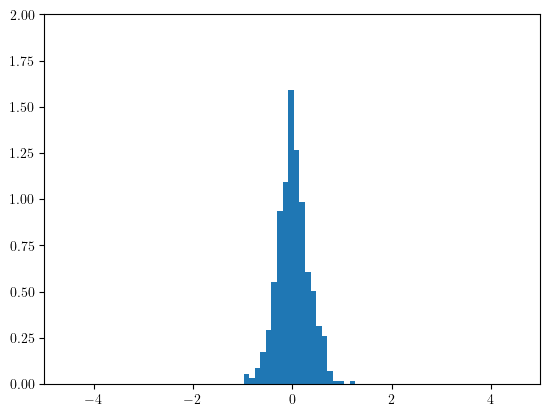

 33%|█████████████▋                           | 1/3 [56:33<1:53:07, 3393.87s/it]

Simpsons parasox measure (features = 50): 0.12290560041980128


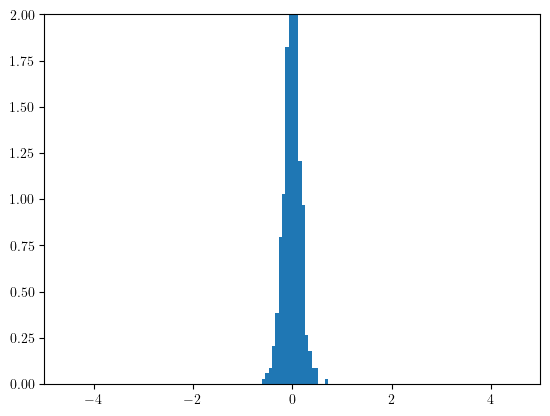

 67%|██████████████████████████             | 2/3 [2:20:36<1:12:43, 4363.86s/it]

Simpsons parasox measure (features = 100): 0.10005189347777466


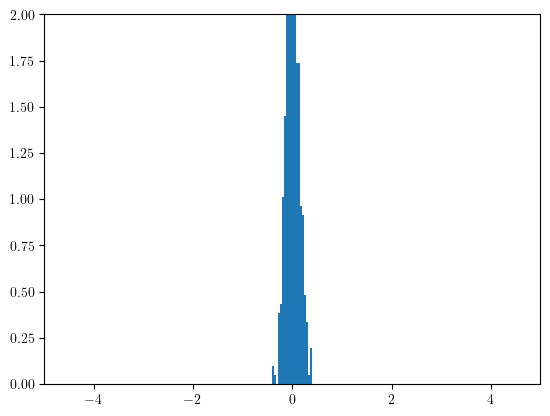

100%|█████████████████████████████████████████| 3/3 [4:15:55<00:00, 5118.55s/it]


In [13]:
# num_features_list = [5, 10, 50, 500]
num_features_list = [5, 50, 100]
n_datasets = 512

dfs = []

for num_features in tqdm(num_features_list):

    
    def sample_dataset():
        _, _, A, Y, Y0, Y1 = generate_single_dataset(
            dataset_id=0,
            num_samples=10000,
            num_features=num_features,
            output_dir='DATA_standard/training_data',
            seed_offset=np.random.randint(n_datasets**3)
        )
        return (A, Y, Y0, Y1)

    results = Parallel(n_jobs=10)(delayed(sample_dataset)() for _ in range(n_datasets))

    results = np.array(results).swapaxes(0, 1).swapaxes(1, 2)
    A, Y, Y0, Y1 = results[0], results[1], results[2], results[3]

    ates = (Y1/Y.std(0, keepdims=True) - Y0/Y.std(0, keepdims=True)).mean(0)
    means_diff = ((A * Y/Y.std(0, keepdims=True)).sum(0) / A.sum(0)) - (((1.0 - A) * Y/Y.std(0, keepdims=True)).sum(0) / (1.0 - A).sum(0))

    difss = ates - means_diff 
    # difss = difss[~difss.isnan()]
    difss = difss[(difss > -5.0) & (difss < 5.0)]

    

    print(f"Simpsons parasox measure (features = {num_features}):", np.nanmean(np.abs(difss)))

    plt.hist(difss, density=True, bins=20)
    plt.xlim(-5, 5)
    plt.ylim(0.0, 2.0)
    plt.show()

    dfs.append(pd.DataFrame({'sample': difss}))

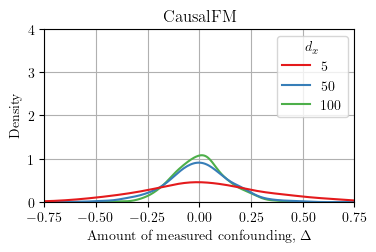

Too few nodes in the prior
Too few nodes in the prior
Too few nodes in the prior
Too few nodes in the prior
Too few nodes in the prior
Too few nodes in the prior
Too few nodes in the prior
Too few nodes in the prior
Too few nodes in the prior
Too few nodes in the prior
Too few nodes in the prior
Too few nodes in the prior
Too few nodes in the prior
Too few nodes in the prior
Too few nodes in the prior
Too few nodes in the prior
Too few nodes in the prior
Too few nodes in the prior
Too few nodes in the prior
Too few nodes in the prior
Too few nodes in the prior
Too few nodes in the prior
Too few nodes in the prior
Too few nodes in the prior
Too few nodes in the prior
Too few nodes in the prior
Too few nodes in the prior
Too few nodes in the prior
Too few nodes in the prior
Too few nodes in the prior
Too few nodes in the prior
Too few nodes in the prior
Too few nodes in the prior
Too few nodes in the prior
Too few nodes in the prior
Too few nodes in the prior
Too few nodes in the prior
T

In [18]:
df = pd.concat(dfs, keys=num_features_list)
df = df.reset_index()

df = df.rename(columns={'sample': sample_name,  'level_0': dim_cov_name})

fig, ax = plt.subplots(figsize=(4, 2.25))
sns.kdeplot(df, x=sample_name, hue=dim_cov_name, palette='Set1', ax=ax)
plt.ylim(0.0, 4)
plt.xlim(-0.75, 0.75)
plt.grid()
plt.title('CausalFM')

plt.savefig(f'{FIGURES_PATH}/causalfm-bias.pdf', bbox_inches = 'tight', pad_inches = 0.1)

<Axes: xlabel='Amount of measured confounding, $\\Delta$', ylabel='Density'>

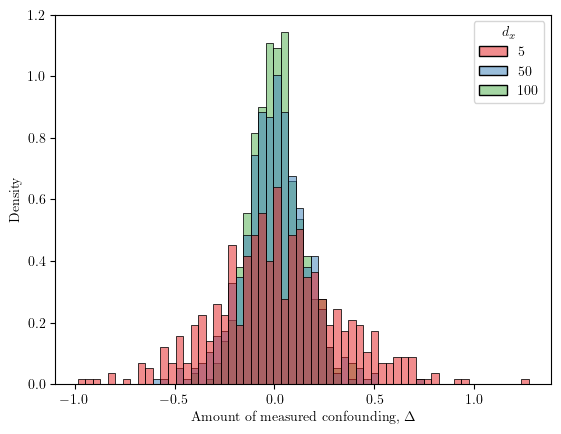

In [24]:
sns.histplot(df, x=sample_name, hue=dim_cov_name, palette='Set1', stat='density')